# 10 — Weather & climate on one grid: GOES-19 + CHIRPS

Two very different data sources, one Major TOM grid:

- **GOES-19 ABI** — geostationary weather imager (channel C07, 2025-12-25 15:00 UTC — a stormy day over Córdoba), via the `aereo-search-aws-goes` + `aereo-read-satpy` plugins. Native resolution ~2 km.
- **CHIRPS daily precipitation** — a climate dataset, via the third-party [`aereo-earthlens`](https://github.com/frandorr/aereo-earthlens) plugin (a wrapper around [earthlens](https://github.com/serapeum-org/earthlens), ~48 weather/climate providers). Native resolution ~5 km. **No credentials needed.** We pull the **week ending 2025-12-25** and accumulate it — a single day's rain map is mostly zeros (dry), while the weekly accumulation shows the full weather pattern.

Both jobs use `reproject_mode="grid"` at their own native-ish resolution (2 km / 5 km): each output artifact **is** one grid cell, so joining weather and climate per cell is a plain catalog merge. The 50 km grid keeps the coarse CHIRPS pixels meaningful — pairing 10 m Sentinel-2 with 5 km CHIRPS would waste pixels; GOES-19 is the right weather partner at this scale.

In [1]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]" aereo-search-aws-goes aereo-read-satpy \
    "git+https://github.com/frandorr/aereo-earthlens.git#subdirectory=projects/aereo-earthlens"

In [2]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
for name in ["job_goes19.yaml", "job_chirps.yaml"]:
    urllib.request.urlretrieve(
        f"{GITHUB_RAW}/examples/config/{name}",
        f"config/{name}",
    )

# AOI files
for name in ["cordoba.geojson"]:
    urllib.request.urlretrieve(
        f"{GITHUB_RAW}/examples/config/aoi/{name}",
        f"config/aoi/{name}",
    )

## Configs used in this notebook

`job_goes19.yaml` searches GOES-19 ABI L1b on public AWS storage and reads it with Satpy, reprojecting to 2 km grid cells. `job_chirps.yaml` uses the earthlens plugin — `search_earthlens` synthesizes asset rows from the `collections` mapping (earthlens data source → variables), and `read_earthlens` downloads the rasters:

```yaml
search:
  _target_: aereo.earthlens.search_earthlens
  _partial_: true
  collections:
    chc: [precipitation]   # CHIRPS daily precipitation
  ...
reproject:
  _target_: aereo.builtins.reproject_odc   # <- builtin stage, NOT the plugin
  _partial_: true
reproject_mode: grid
resolution: 5000           # CHIRPS native ~5 km
```

Note the plugin provides **only search and read**. Reprojection is a separate pipeline stage — here the core builtin `reproject_odc` — so the plugin stays small and any reprojector could be swapped in.

Both configs already point at the Córdoba AOI (~195 × 137 km); we only rename the jobs and their output folders.

In [3]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job_goes = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_goes19",
    overrides=[
        "name=goes19_cordoba",
        "output_uri=/tmp/aereo_weather/goes19",
        # A stormy afternoon over Córdoba.
        "search.start_datetime=2025-12-25T15:00:00Z",
        "search.end_datetime=2025-12-25T15:10:59Z",
    ],
)

job_chirps = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_chirps",
    overrides=["name=chirps_cordoba", "output_uri=/tmp/aereo_weather/chirps"],
)

In [4]:
# GOES reads NetCDF via satpy/HDF5, which is not thread-safe ->
# run with processes (no use_threads), as in the GOES-19 notebook.
local_exec = LocalExecutor(workers=-1, cache=TaskResultCache())

def run(job: ExtractionJob):
    assets = job.search()
    tasks = job.build_tasks(assets)
    artifacts = job.execute(tasks, executor=local_exec)
    catalog = job.write_catalog(artifacts)
    print(f"{job.name}: {len(artifacts)} artifacts -> {catalog}")
    return artifacts, catalog

goes_artifacts, catalog_goes = run(job_goes)

2026-07-27 14:07:00 [info     ] search_called                  provider=search_aws_goes


2026-07-27 14:07:02 [info     ] build_tasks_start              assets=2 builder=build_grouped_tasks


2026-07-27 14:07:02 [info     ] execute_start                  executor=LocalExecutor task_count=2


/home/fran/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


goes19_cordoba: 34 artifacts -> /tmp/aereo_weather/goes19/artifacts.parquet


In [5]:
from datetime import date, timedelta

# One job per day: each day lands as its own rows in the catalog,
# identified by start_time (the Major TOM index way).
chirps_catalogs = []
start = date(2025, 12, 19)
for i in range(7):
    day = start + timedelta(days=i)
    job_day = ExtractionJob.load_from_config(
        config_dir="config",
        config_name="job_chirps",
        overrides=[
            f"name=chirps_{day:%Y%m%d}",
            f"output_uri=/tmp/aereo_weather/chirps/{day:%Y%m%d}",
            f"search.start_datetime={day}T00:00:00Z",
            f"search.end_datetime={day}T23:59:59Z",
        ],
    )
    chirps_artifacts, catalog_day = run(job_day)  # keeps the last (wettest) day
    chirps_catalogs.append(catalog_day)

2026-07-27 14:07:03 [info     ] search_called                  provider=search_earthlens


2026-07-27 14:07:03 [debug    ] earthlens_search_synthesized   assets=1 data_sources=1


2026-07-27 14:07:03 [info     ] build_tasks_start              assets=1 builder=build_grouped_tasks


2026-07-27 14:07:04 [info     ] execute_start                  executor=LocalExecutor task_count=1


chirps_20251219: 17 artifacts -> /tmp/aereo_weather/chirps/20251219/artifacts.parquet
2026-07-27 14:07:05 [info     ] search_called                  provider=search_earthlens


...

chirps_20251224: 17 artifacts -> /tmp/aereo_weather/chirps/20251224/artifacts.parquet
2026-07-27 14:07:11 [info     ] search_called                  provider=search_earthlens


2026-07-27 14:07:11 [debug    ] earthlens_search_synthesized   assets=1 data_sources=1


2026-07-27 14:07:11 [info     ] build_tasks_start              assets=1 builder=build_grouped_tasks


2026-07-27 14:07:11 [info     ] execute_start                  executor=LocalExecutor task_count=1


chirps_20251225: 17 artifacts -> /tmp/aereo_weather/chirps/20251225/artifacts.parquet


## Join: one Major TOM index for weather + climate

Both jobs used `reproject_mode="grid"`, so each artifact **is** a grid cell — no shared whole-AOI rasters here (contrast with notebook 08, where windowing was needed). The merged index is a plain concatenation: one row per (grid cell, scene), repeated cells identified by `start_time`/`end_time`.

In [6]:
import geopandas as gpd
import pandas as pd

cat_goes = gpd.read_parquet(catalog_goes).assign(slot="goes19")
cat_chirps = pd.concat(
    [gpd.read_parquet(c) for c in chirps_catalogs], ignore_index=True
).assign(slot="chirps")

merged = (
    pd.concat([cat_goes, cat_chirps], ignore_index=True)
    .sort_values(["grid_cell", "start_time"])
    .reset_index(drop=True)
)

index_path = "/tmp/aereo_weather/majortom_index.parquet"
merged.to_parquet(index_path)

common_cells = sorted(set(cat_goes.grid_cell) & set(cat_chirps.grid_cell))
print(f"{len(merged)} rows -> {index_path}")
print(f"{len(common_cells)} grid cells observed by BOTH sources")
merged[["grid_cell", "slot", "start_time", "uri"]].head(6)

153 rows -> /tmp/aereo_weather/majortom_index.parquet
17 grid cells observed by BOTH sources


,grid_cell,slot,start_time,uri
0,67D_120L,chirps,2025-12-19,/tmp/aereo_weather/chirps/20251219/job-chirps_...
1,67D_120L,chirps,2025-12-20,/tmp/aereo_weather/chirps/20251220/job-chirps_...
2,67D_120L,chirps,2025-12-21,/tmp/aereo_weather/chirps/20251221/job-chirps_...
3,67D_120L,chirps,2025-12-22,/tmp/aereo_weather/chirps/20251222/job-chirps_...
4,67D_120L,chirps,2025-12-23,/tmp/aereo_weather/chirps/20251223/job-chirps_...
5,67D_120L,chirps,2025-12-24,/tmp/aereo_weather/chirps/20251224/job-chirps_...


## The full picture: one day of weather

`plot_artifact_patches` stitches the per-cell artifacts back into the full scene. First GOES-19 C07, then CHIRPS precipitation for 2025-12-25 — a genuinely wet day.

A note on "holes" in daily precipitation maps: they are almost never missing data (these CHIRPS rasters have 0% NaN). White is a real **0 mm** — on any given day most of a region sees no rain. The informative view is an accumulation, which is what we build next.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


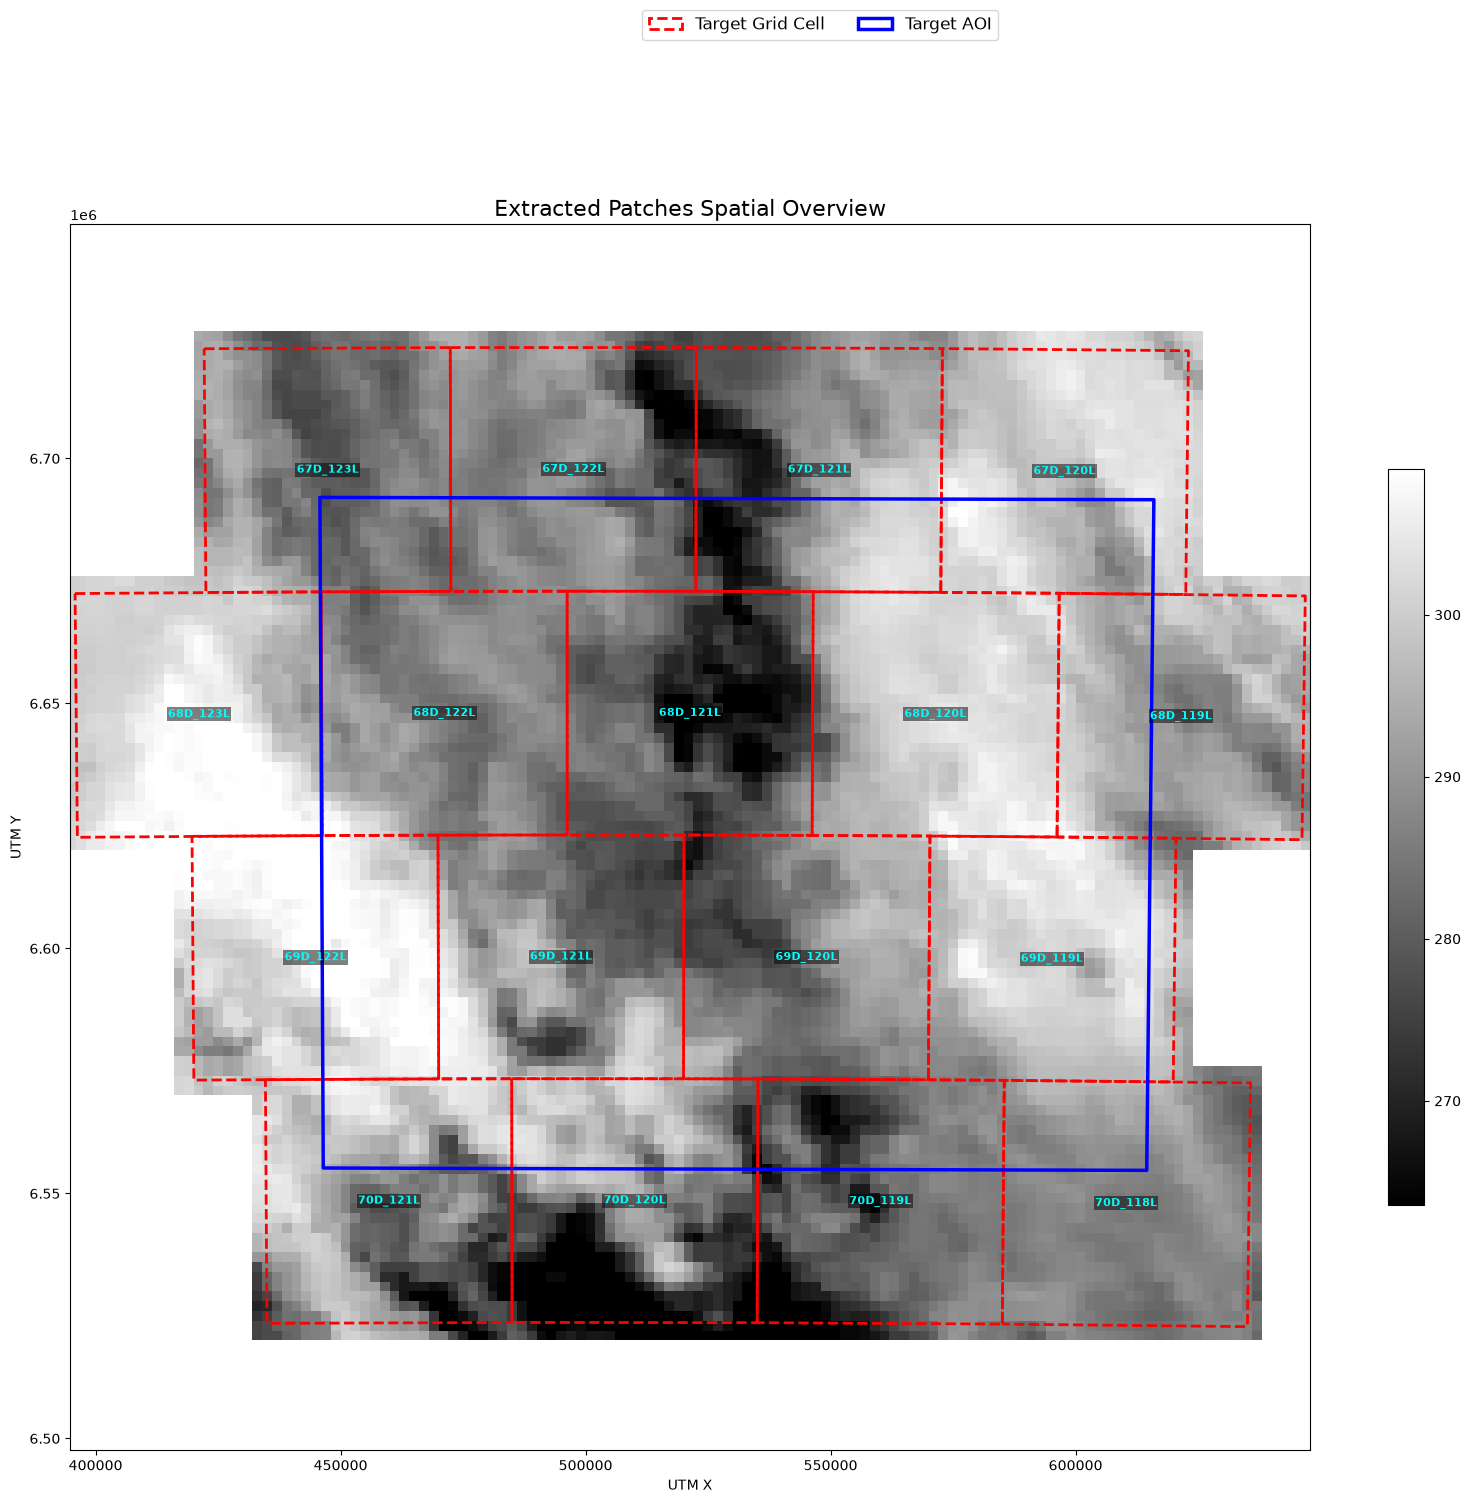

In [7]:
from aereo.viz import plot_artifact_patches

fig, ax = plot_artifact_patches(
    goes_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="gray",
    aoi=job_goes.target_aoi,
    aoi_edgecolor="blue",
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


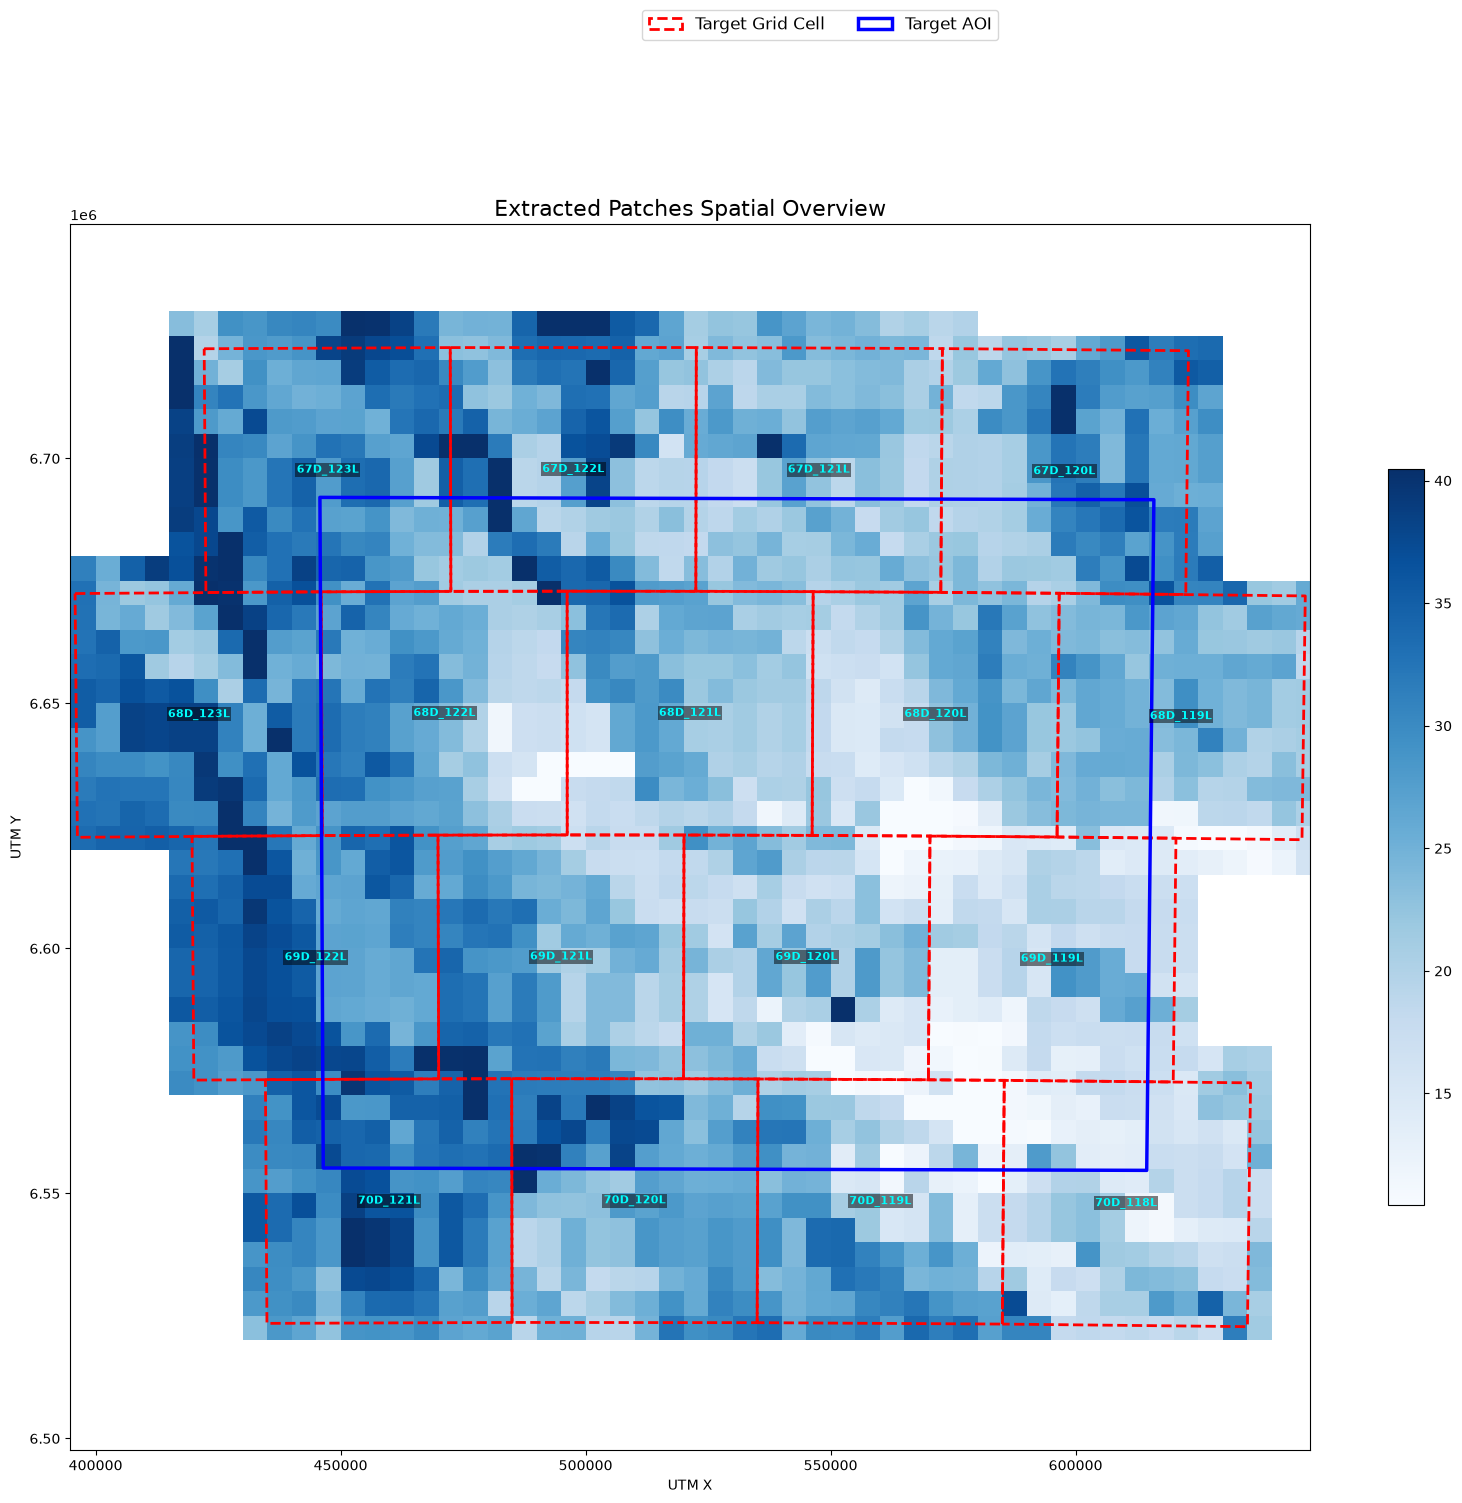

In [8]:
fig, ax = plot_artifact_patches(
    chirps_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="Blues",
    aoi=job_chirps.target_aoi,
    aoi_edgecolor="blue",
)

## Filling the map: accumulate the week

Each day is already a separate row per cell in our index (identified by `start_time`), so accumulating is a per-cell **sum** across the referenced rasters. We write the accumulated rasters as derived products and point a small catalog at them — precipitation adds up, unlike temperature or reflectance, which you would average instead.


In [9]:
import os

import numpy as np
import rasterio

accum_dir = "/tmp/aereo_weather/chirps_accum"
os.makedirs(accum_dir, exist_ok=True)

accum_rows = []
for cell_id in common_cells:
    rows = cat_chirps[cat_chirps.grid_cell == cell_id].sort_values("start_time")
    arrs, profile = [], None
    for uri in dict.fromkeys(rows.uri):
        with rasterio.open(uri) as src:
            arrs.append(src.read(1).astype("float32"))
            profile = src.profile
    accum = np.nansum(np.stack(arrs), axis=0)  # weekly accumulation, mm
    out_uri = f"{accum_dir}/{cell_id}_week.tif"
    profile.update(count=1, dtype="float32", nodata=None)
    with rasterio.open(out_uri, "w", **profile) as dst:
        dst.write(accum, 1)
    row = rows.iloc[0].copy()
    row["uri"] = out_uri
    accum_rows.append(row)

accum_artifacts = gpd.GeoDataFrame(
    accum_rows,
    geometry=gpd.GeoSeries([r["geometry"] for r in accum_rows], crs=cat_chirps.crs),
)
# plot_artifact_patches needs cell_utm_footprint as a GeoSeries too
accum_artifacts["cell_utm_footprint"] = gpd.GeoSeries(
    accum_artifacts["cell_utm_footprint"].values,
    crs=f"EPSG:{accum_artifacts['cell_utm_crs'].iloc[0]}",
)
print(f"{len(accum_artifacts)} accumulated rasters in {accum_dir}")

17 accumulated rasters in /tmp/aereo_weather/chirps_accum


/tmp/ipykernel_207633/1913741027.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arrs.append(src.read(1).astype("float32"))
/tmp/ipykernel_207633/1913741027.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arrs.append(src.read(1).astype("float32"))
/tmp/ipykernel_207633/1913741027.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arrs.append(src.read(1).astype("float32"))
/tmp/ipykernel_207633/1913741027.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=Fal

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


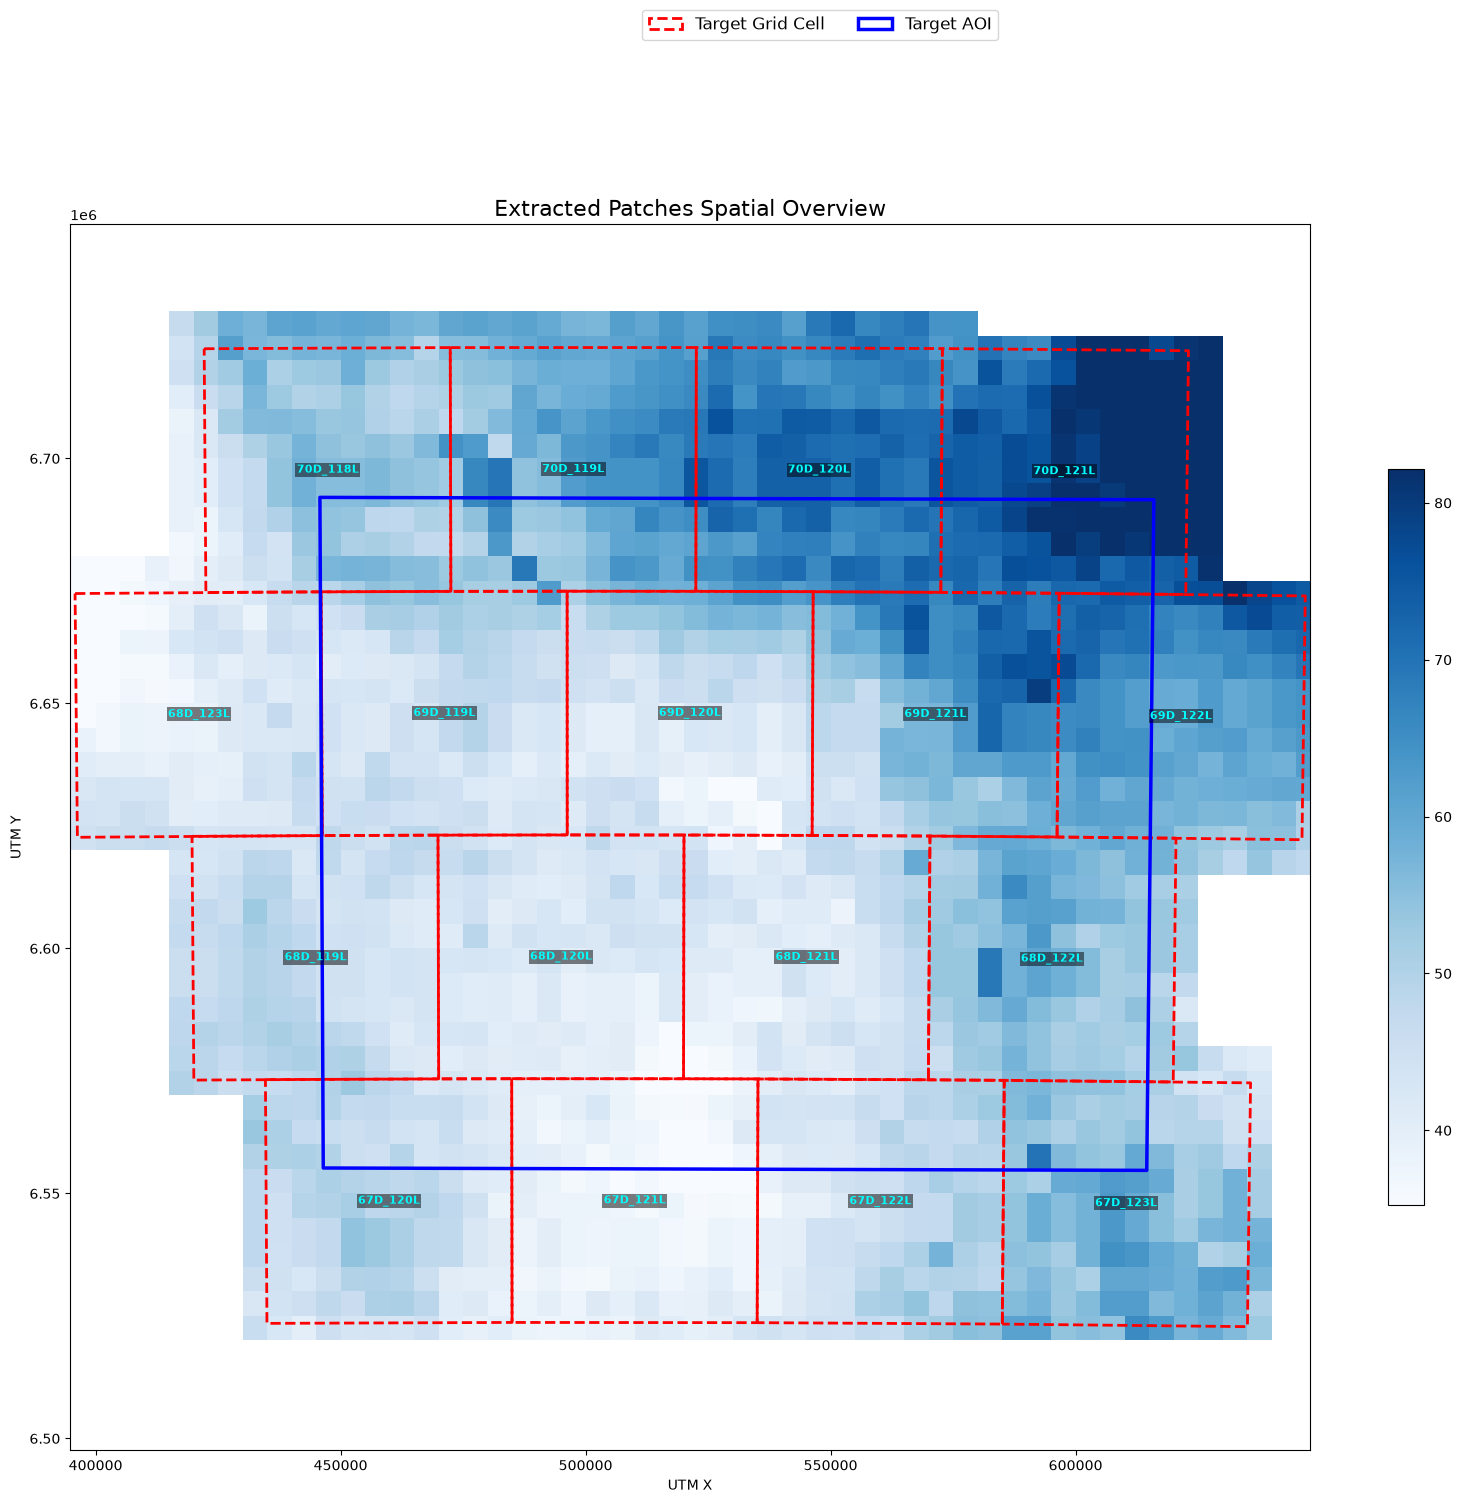

In [10]:
fig, ax = plot_artifact_patches(
    accum_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="Blues",
    aoi=job_chirps.target_aoi,
    aoi_edgecolor="blue",
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


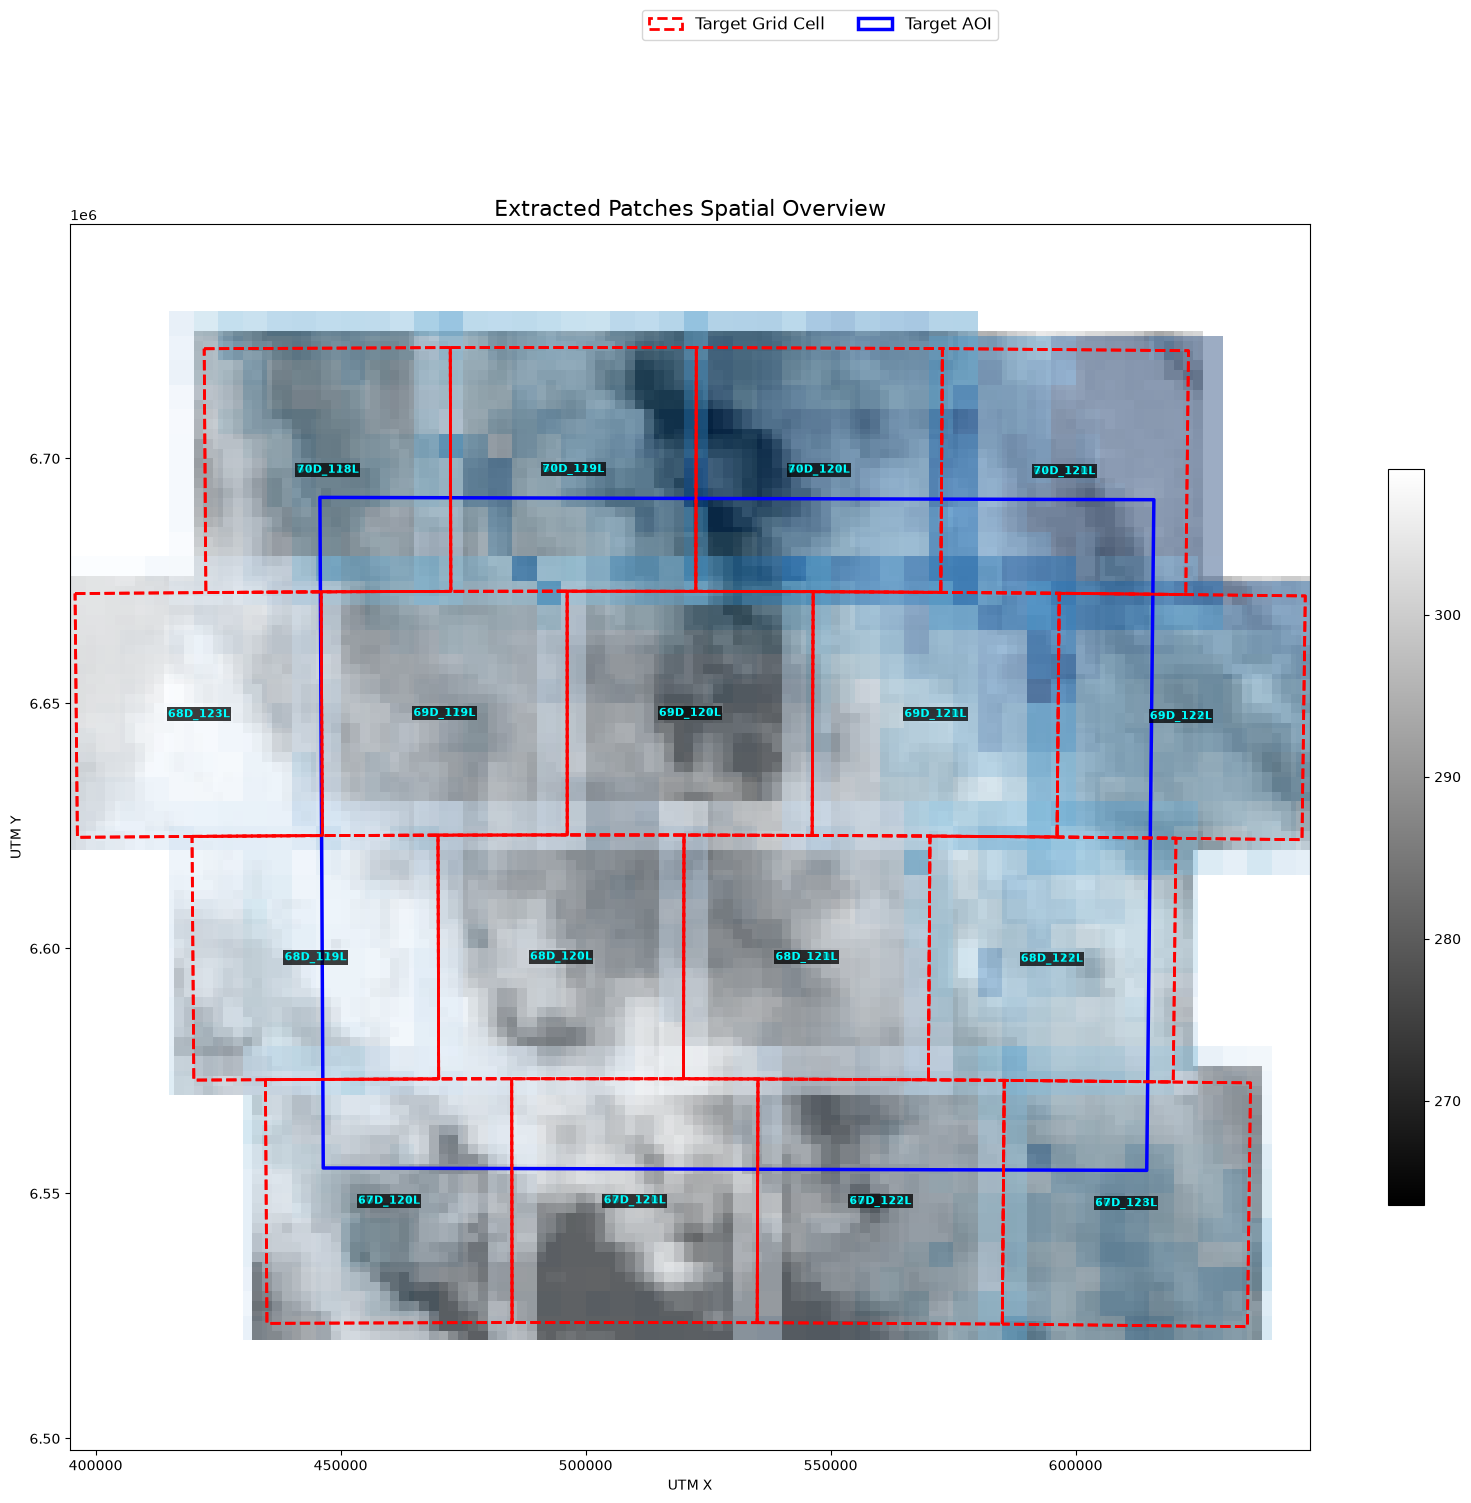

In [11]:
# Overlay: GOES-19 C07 as base, weekly CHIRPS accumulation on top.
fig, ax = plot_artifact_patches(
    goes_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="gray",
    aoi=job_goes.target_aoi,
    aoi_edgecolor="blue",
)
fig, ax = plot_artifact_patches(
    accum_artifacts, ds_factor=1, stretch="percentile", cmap="Blues", ax=ax, alpha=0.4
)